environment: mtl-aligner

In [ ]:
import pandas as pd
import os
import numpy as np

import matplotlib.pyplot as plt


seed = 40
RNG = np.random.default_rng(seed)

import spacy
nlp = spacy.load("en_core_web_lg")
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold
from sklearn.metrics.pairwise import cosine_similarity

from scipy.spatial.distance import pdist
from scipy.stats import spearmanr, pearsonr
from scipy.stats import zscore

## Params

In [333]:
task = 'lst2'
sub = '41'

eeg_file = f'../data/{sub}/resp_pp/resp{task}_cropped.npy'
onset_dir = './onset_csv_stimspk' #only works for sub 41/128
onset_files = sorted(os.listdir(onset_dir))

tmin = -0.2
tmax = 0.2
step_size = 0.02
window_size = 0 #set to 0 if taking a single timepoint

n_perms = 500

# pca_y = False
# pca_x = False

FS = 100

## Load data

In [334]:
# SELECT ELECTRODES
elecs = 'spec elec by r'

#by t-value
elec_tvals_df = pd.read_csv('../data/sig_elecs/elec_41.csv')
elec_tvals_df["electrode_indices"] = elec_tvals_df["electrode_indices"].apply(
    lambda x: [int(i) for i in x.split(",")]
)
aud_elec = elec_tvals_df[elec_tvals_df['type']=='auditory']['electrode_indices'].values[0]
mot_elec = elec_tvals_df[elec_tvals_df['type']=='motor']['electrode_indices'].values[0]

#by encoding performance
pre_run_ID = '20260903_103832_preonly'
post_run_ID = '20260902_184516_postonly'
prepost_run_ID = '20260902_180643_full'
df_pre = pd.read_csv(f'../[ANALYSIS]_motor_trajectories/fwd_trf_results/{pre_run_ID}/results.csv')
df_post = pd.read_csv(f'../[ANALYSIS]_motor_trajectories/fwd_trf_results/{post_run_ID}/results.csv')
df_prepost = pd.read_csv(f'../[ANALYSIS]_motor_trajectories/fwd_trf_results/{prepost_run_ID}/results.csv')

spec_elec = df_prepost[(df_prepost['subject'] == int(sub)) & (df_prepost['sig_spec']) & (df_prepost['task'] == task)]['electrode'].values
tv_elec = df_prepost[(df_prepost['subject'] == int(sub)) & (df_prepost['sig_tv']) & (df_prepost['task'] == task)]['electrode'].values


# LOAD EEG
eeg = np.load(eeg_file)
if elecs == 'aud elec by tval':
    eeg = eeg[:,:, aud_elec ]
elif elecs == 'mot_elec by tval':
    eeg = eeg[:, :, mot_elec]
elif elecs == 'spec elec by r':
    eeg = eeg[:, :, spec_elec]
elif elecs == 'tv elec by r':
    eeg = eeg[:, :, tv_elec]

print(eeg.shape)

(60, 100, 16)


In [335]:
#data loading helpers
def crop_trial_onsets(trial_eeg, trial_onsets, tmin, tmax, fs):
    cropped_data = []
    dropped_words_idx = []

    n_samples = int((tmax - tmin) * fs)

    for idx, onset in enumerate(trial_onsets):

        onset_idx = int(onset * fs)

        start_idx = onset_idx + int(tmin * fs)
        end_idx = start_idx + n_samples
        if tmin == tmax:
            if start_idx < 0 or start_idx >= trial_eeg.shape[0]:
                dropped_words_idx.append(idx)
                continue
            cropped_data.append(trial_eeg[start_idx, :])
        else:
            if start_idx < 0 or end_idx > trial_eeg.shape[0]:
                dropped_words_idx.append(idx)
                continue
            cropped_data.append(trial_eeg[start_idx:end_idx, :])

    return np.stack(cropped_data), np.array(dropped_words_idx)

def assemble_Xy(eeg, onset_files, **kwargs):
    """
    Assemble the feature matrix X and target vector y from EEG data and onset files.

    Parameters:
    eeg (numpy.ndarray): The EEG data.
    onset_files (list): A list of onset file names.
    kwargs: Additional keyword arguments for cropping.

    Returns:
    tuple: A tuple containing the feature matrix X and target vector y.
    """
    X = []
    y = []
    
    for tr, trial_eeg in enumerate(eeg):
        onset_file = onset_files[tr]
        onset_df = pd.read_csv(os.path.join(onset_dir, onset_file))
        trial_onsets = onset_df[onset_df['tier']=='words']['start'].values
        trial_words = onset_df[onset_df['tier']=='words']['label'].values
        cropped_data, dropped_words_idx = crop_trial_onsets(trial_eeg, trial_onsets, **kwargs)
        X.append(cropped_data)
        trial_words_cropped =  trial_words[~np.isin(np.arange(len(trial_words)), dropped_words_idx)]
        y.extend(trial_words_cropped)  # Assuming we want to predict onsets

    return np.concatenate(X), np.array(y)

def balance_classes(X, y_embed_raw, y_word, max_per_word):

    keep_idx = []

    for word in np.unique(y_word):
        idx = np.where(y_word == word)[0]

        # Keep at most max_per_word occurrences
        n_keep = min(len(idx), max_per_word)

        selected = RNG.choice(idx, size=n_keep, replace=False)
        keep_idx.extend(selected)

    keep_idx = np.array(keep_idx)

    # Apply same indices to everything
    X_bal = X[keep_idx]
    y_embed_bal = y_embed_raw[keep_idx]

    return X_bal, y_embed_bal


In [338]:
t = tmin
p_perms = []
r_overtime = []
    
while t < tmax:
    window_begin = t
    window_end = t+window_size

    X_3d, y_word = assemble_Xy(eeg, onset_files, tmin=window_begin, tmax=window_end, fs=FS)

    # make X 2d (if it's not already, i.e. contains one timepoint)
        # by vectorizing
    # n_words, n_times, n_channels = X_3d.shape
    # X = X_3d.reshape(n_words, n_times * n_channels)

        # by averaging
    if len(X_3d.shape) > 2:
        X = np.mean(X_3d, axis = 1)
    
    else:
        X = X_3d.copy()

    #get word embeddings 
    y_embed_raw = np.array([nlp(str(word))[0].vector for word in y_word])

    #balance classes
    X_bal, y_bal = balance_classes(X, y_embed_raw, y_word, max_per_word=1)
    X_z = zscore(X_bal, axis=0) 

    ## PCA????
    # n_components = min(10, X_bal.shape[0] - 1)  # cap by n_words too, not just an arbitrary 10
    # X_pca = PCA(n_components=0.95).fit_transform(X_z)
    # y_bal = PCA(n_components=0.95).fit_transform(y_bal)

    X_pca = X_z.copy()

    ### AVOID NANS IN THE RDM BY REMOVING ZERO VARIANCE ROWS/COLUMNS
    # Remove rows with zero variance
    row_var = np.var(X_pca, axis=1)
    keep_rows = row_var != 0

    X_pca = X_pca[keep_rows]
    y_bal = y_bal[keep_rows]
    
    # Remove columns with zero variance
    col_var = np.var(X_pca, axis=0)
    X_pca = X_pca[:, col_var != 0]

    # calculate dissimilarity matrix
    rdm_neural = pdist(X_pca, metric='correlation')
    rdm_words = pdist(y_bal, metric='cosine')  

    # OBSERVED CORRELATION
    r_obs, _ = spearmanr(rdm_words, rdm_neural)
    r_overtime.append(r_obs)

    #permutation test
    r_null = np.zeros(n_perms)
    for i in range(n_perms):
        y_shuf = np.random.permutation(y_bal)  # shuffles rows, i.e. word labels
        rdm_words_shuf = pdist(y_shuf, metric='cosine')
        r_null[i], _ = spearmanr(rdm_words_shuf, rdm_neural)


    p_perm = (np.sum(r_null >= r_obs) + 1) / (n_perms + 1)  # +1 correction, standard practice
    print(window_begin, window_end, p_perm)

    p_perms.append(p_perm)


    t += step_size


-0.2 -0.2 0.8662674650698603
-0.18000000000000002 -0.18000000000000002 0.3772455089820359
-0.16000000000000003 -0.16000000000000003 0.2315369261477046
-0.14000000000000004 -0.14000000000000004 0.34331337325349304
-0.12000000000000004 -0.12000000000000004 0.16167664670658682
-0.10000000000000003 -0.10000000000000003 0.10578842315369262
-0.08000000000000003 -0.08000000000000003 0.22954091816367264
-0.060000000000000026 -0.060000000000000026 0.5049900199600799
-0.04000000000000002 -0.04000000000000002 0.36127744510978044
-0.02000000000000002 -0.02000000000000002 0.5848303393213573
-2.0816681711721685e-17 -2.0816681711721685e-17 0.6786427145708582
0.01999999999999998 0.01999999999999998 0.3193612774451098
0.03999999999999998 0.03999999999999998 0.7005988023952096
0.059999999999999984 0.059999999999999984 0.3393213572854291
0.07999999999999999 0.07999999999999999 0.25748502994011974
0.09999999999999999 0.09999999999999999 0.20758483033932135
0.12 0.12 0.041916167664670656
0.1399999999999999

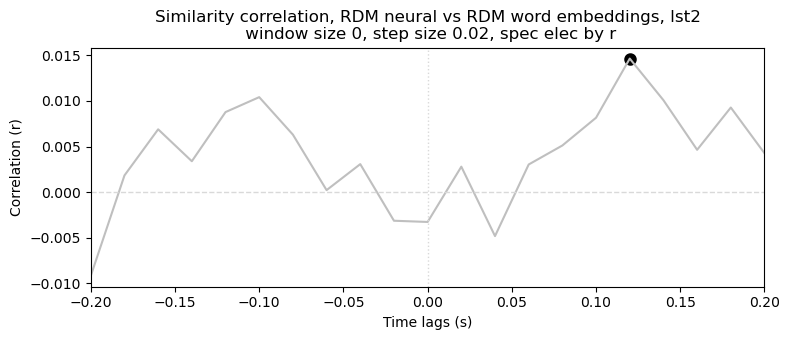

In [339]:
times = np.linspace(tmin, tmax, len(r_overtime))

r = np.array(r_overtime)
p = np.array(p_perms)
sig = p < 0.05

plt.figure(figsize=(8, 3.5))

# Thin baseline
plt.plot(times, r, color="0.75", lw=1.5)

# Bold only for significant time points
plt.scatter(times, np.where(sig, r, np.nan),
         color="black", lw=3)

# Reference lines
plt.axhline(0, color="0.85", ls="--", lw=1)
plt.axvline(0, color="0.85", ls=":", lw=1)

plt.xlim(times[0], times[-1])
plt.xlabel("Time lags (s)")
plt.ylabel("Correlation (r)")
plt.title(f'Similarity correlation, RDM neural vs RDM word embeddings, {task}\n window size {window_size}, step size {step_size}, {elecs}')
plt.tight_layout()
plt.show()

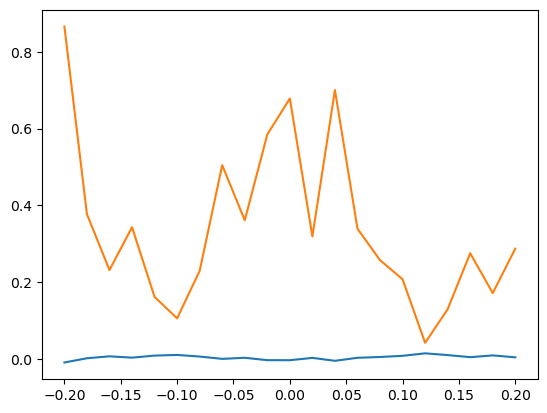

In [340]:

times = np.linspace(tmin, tmax, len(r_overtime))
plt.plot(times,r_overtime)
plt.plot(times,p_perms)